Imports

In [1]:
import sys
sys.path.append('imports')

%load_ext autoreload
%autoreload 2
import pickle as pkl
import numpy as np
import json
from os.path import sep
import cv2
from glob import glob
import matplotlib
import matplotlib.pyplot as plt
import select_files
import scienceplots
from scipy.interpolate import interp1d
from generate_training import modelist
import power_length_analysis
import Meta_classifier
import socket
import pandas as pd
import phase_analysis_complete
from tqdm.autonotebook import tqdm
import joblib


# Sets style for plots
plt.style.use(['science', 'ieee', 'no-latex'])

plt.rcParams.update({
    'figure.figsize': [7.2, 7.2],
    'font.size': 12,
    'figure.dpi': 100,
    'savefig.dpi': 300
})

if socket.gethostname() == 'ph-photonbec5':
    sys_path = r'D:/Data/2024'
if socket.gethostname() == 'r018104':
    sys_path = r'C:\Users\natak\OneDrive - Imperial College London\Documents\University\Year 4\MSci Project-r018104\All_data\202408'
if socket.gethostname() == 'Louis_PC':
    sys_path = r'C:\Users\Pouis\OneDrive - Imperial College London\PBEC\Data'
else:
    # print(r'C:\Users\Pouis\OneDrive - Imperial College London\PBEC\Data')
    raise Exception('unrecognised computer')


c:\Users\Pouis\Documents\Uni Shit\Masters\PhaseGit\Supervised-clustering-phase-pBEC\MultiMode Analysis\imports\generate_training.py:19: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


# Open and format data

In [2]:
# t_stamps = ['20240731_152730', '20240731_155505']
# List of timestamps for dataset
t_chunks = [['20240821_165243', '20240821_202907'], 
            ['20240822_112634' , '20240822_142936'],
            ['20240822_192330', '20240823_002423'],
            ['20240823_102053' , '20240823_135531'], 
]

image_dir = sys_path
# Make new folder or everything will be deleted
crop_dir = sys_path + r'\Cropped_Images\21_23_crop'
# Gets list of files and metas from t_chunks
files, metas = select_files.open_img_files(t_chunks, image_dir)
print(len(files))

4800


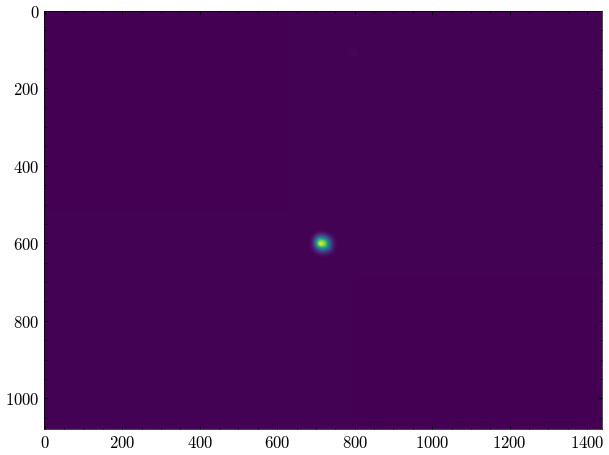

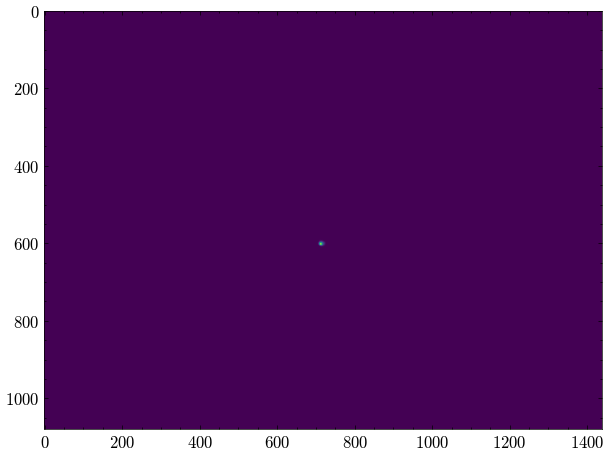

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:   14.1s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:   15.4s
[Parallel(n_jobs=-1)]: Done 1128 tasks      | elapsed:   17.6s
[Parallel(n_jobs=-1)]: Done 2528 tasks      | elapsed:   20.8s


completed crop


[Parallel(n_jobs=-1)]: Done 4800 out of 4800 | elapsed:   25.7s finished


In [3]:
# crops images around an image of bec
bec_file = sys_path + r'\20240822\pbec_20240822_100914_501.0_0.051315789473684204_945.5709228515625_-2.0_.png'
power_length_analysis.bec_crop_centre_fast(bec_file, files, [170, 170], crop_dir)





In [4]:
print(len(files))
files = np.array(glob(crop_dir + sep + '*.png'))
print(len(files))
# Constucts a dictionary of all meta data and images
data = power_length_analysis.data_from_metas_fast(metas, files)

4800
4800


# Select Stimulated Files
Various methods to select. Recommend mean pixel and output power. 
Each method is decribed in doc string.

In [5]:
# stim_mask = select_files.select_stimulated_nd(data)
# stim_mask = select_files.select_stimulated_exp(data, 5)
# stim_mask = select_files.select_stimulated_nd_and_exp(data, 10)
#stim_mask = select_files.select_stimulated_exp_from_filename(data['file'], 1000)
stim_mask1 = select_files.select_stimulated_mean_pixel(data, 20)
stim_mask2 = select_files.select_stimulated_output_power(data, 9e-6)

stim_mask = stim_mask1 & stim_mask2
print('num stimulated:', np.sum(stim_mask))


num stimulated: 2888


# PCA Fits
Fit wavelengths to the PCA. Not good to use if lock drifts a lot. 

20240821202907
938.0824584960938


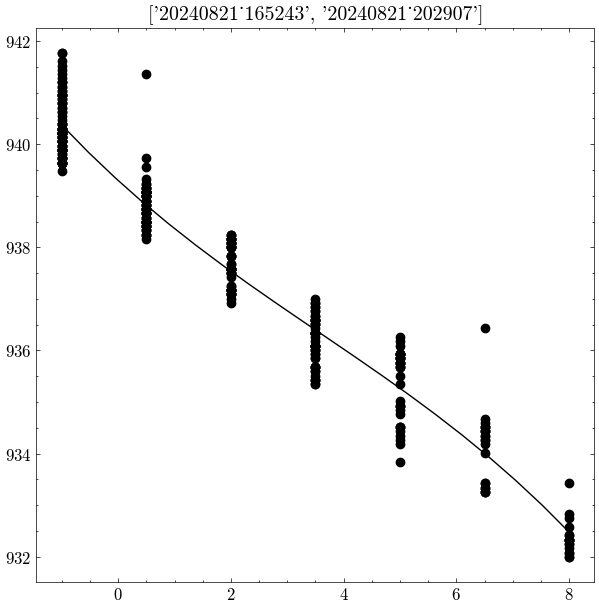

20240822142936
942.9085083007812


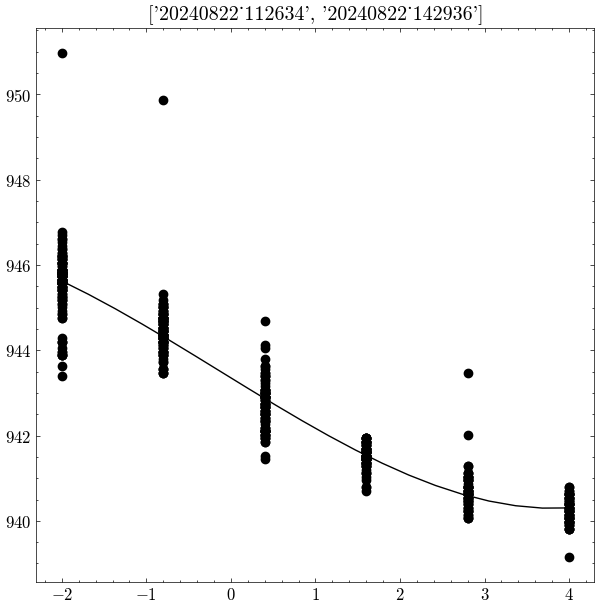

20240823002423
949.7119750976562


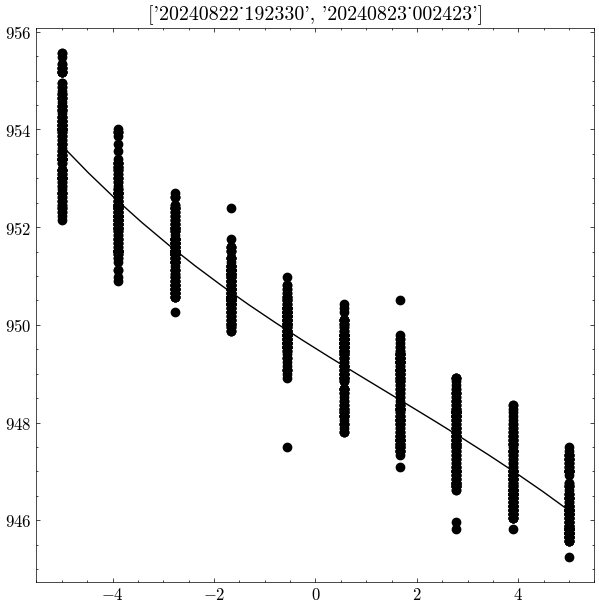

20240823135531
955.0262451171875


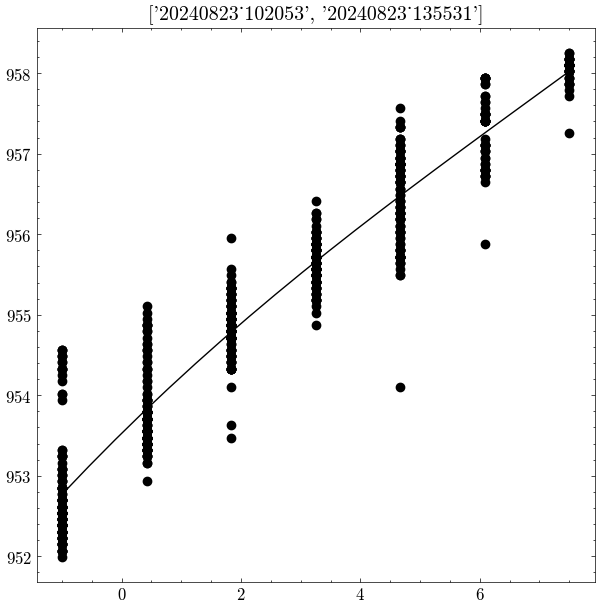

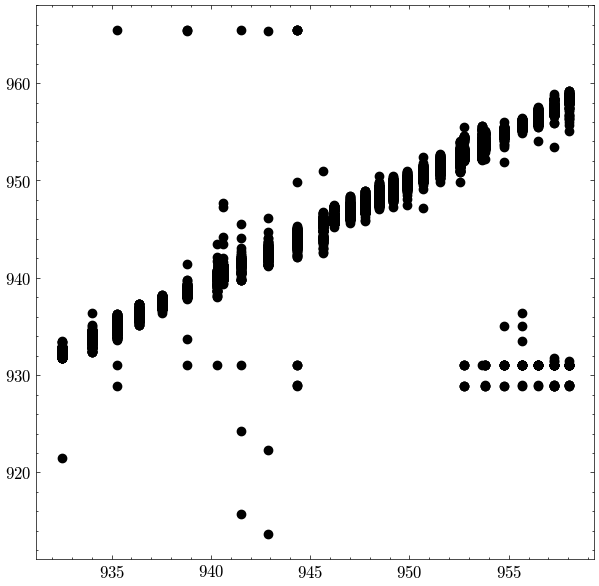

In [6]:


# Fit PCA values to cavity length
if 'pca' not in data.keys():
    print('!')
    png_data = power_length_analysis.data_dict(files)
    data.update({'pca': png_data['pca']})

pca_length = []

for i in t_chunks:
    # Creates mask for stimulated emission and each time cavity is locked
    mint = int(i[0].split('_')[0] + i[0].split('_')[1])
    maxt = int(i[1].split('_')[0] + i[1].split('_')[1])
    print(maxt)
    tmask = (mint <= data['t']) & (data['t'] <= maxt)
    mask = tmask & stim_mask

    # plt.scatter(data['cavity_length'][mask], data['power'][mask])
    # plt.show()
    
    # removes any outlying points
    mean_length = np.median(data['cavity_length'][mask])
    print(mean_length)
    length_mask = (mean_length - 10 <= data['cavity_length']) & (data['cavity_length'] <= mean_length + 10)
    mask = tmask & stim_mask & length_mask

    plt.scatter(data['pca'][mask], data['cavity_length'][mask])
    # plt.show()
    # fits pca values to cavity length
    _, fit = power_length_analysis.fit_pca(data['cavity_length'][mask], data['pca'][mask])
    pca_length += list(fit(data['pca'][tmask]))

    x = np.linspace(min(data['pca'][mask]), max(data['pca'][mask]), 20)
    plt.plot(x, fit(x))
    plt.title(i)
    plt.show()

# Adds pca length to data dictionary
data.update({'pca_length': np.array(pca_length)})

plt.scatter(data['pca_length'], data['cavity_length'])
plt.show()

# Choose Displacement

(Only use if applicable)

In [7]:
import dill
#Choose displacement
print('positions: ', np.unique(data['position']))
positions = np.unique(data['position'])

if socket.gethostname() == 'Louis_PC':
    disp_path = r'C:\Users\Pouis\Documents\Uni Shit\Masters\PhaseGit\Supervised-clustering-phase-pBEC\displacement_func.dill'

with open(disp_path, 'rb') as f:
    disp_func = dill.load(f)

dataset = 2

displacements = np.array(disp_func(positions))
displacements = displacements - min(displacements)
print('Scaled displacements: ', displacements)
pos_mask = select_files.select_position(data, positions[dataset])

#combine the masks
stim_pos_mask = stim_mask & pos_mask
thermal_mask = pos_mask & (~stim_mask)
print(np.sum(stim_pos_mask))


positions:  [      0  571428 1142857 1714285 2285714 2857142 3428571 4000000]
Scaled displacements:  [ 0.          1.8917039   3.78341111  5.67511501  7.56682222  9.45852611
 11.35023332 13.24194053]
403


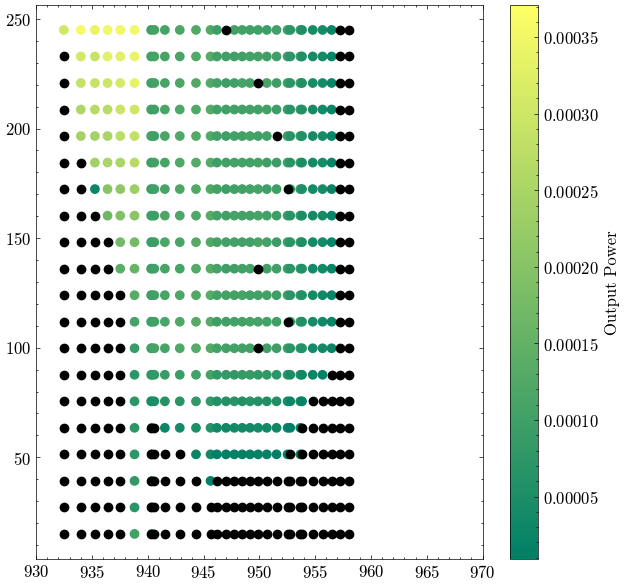

In [8]:

fig, ax = plt.subplots(1, 1)
# Thermal cloud histogram
# power_length_analysis.plot_2dhist(
#     data['cavity_length'][~stim_mask],
#     data['power'][~stim_mask],
#     [910,970], [0,120],
#     'grey', 30, fig = fig, ax = ax, alpha = 1
# )

# # Stimulated emission histogram
# power_length_analysis.plot_2dhist(
#     data['cavity_length'][stim_mask],
#     data['power'][stim_mask],
#     [910,970], [0,120],
#     'orchid', 30, fig = fig, ax = ax, alpha= 1
# )

# print(data['pca_length'][stim_mask])

# Scattered points



scat = ax.scatter(data['pca_length'][stim_pos_mask], data['power'][stim_pos_mask], c=data['meter_reading'][stim_pos_mask],
                  cmap='summer', label='Above Threshold')
ax.scatter(data['pca_length'][thermal_mask], data['power'][thermal_mask], color='black', label='Below Threshold')
ax.set_xlim([930, 970])
cbar = fig.colorbar(scat, ax=ax, label='Output Power')
plt.show()



# Interactive Plot
Colours are random

In [36]:
#
#power_length_analysis.interactive_scatter(data['cavity_length'], data['power'], data['file'], labels_data = np.random.randint(0, 5, size=(len(data['pca_length'][stim_mask]))))

labels = np.ones(len(data['power']))
labels[stim_mask] = 0
labels[-1] = 2

#If only showing stim mask:
labels = np.random.randint(0, 5, len(data['power']))

power_length_analysis.interactive_scatter(data['cavity_length'][mask], data['power'][mask], data['file'][mask], labels_data=labels[mask])

# Binned plot
Use this to test out the best bin count. This uses the physt module, and tries to make bins with the same number of points per bin. Don't increase the bin count too much.


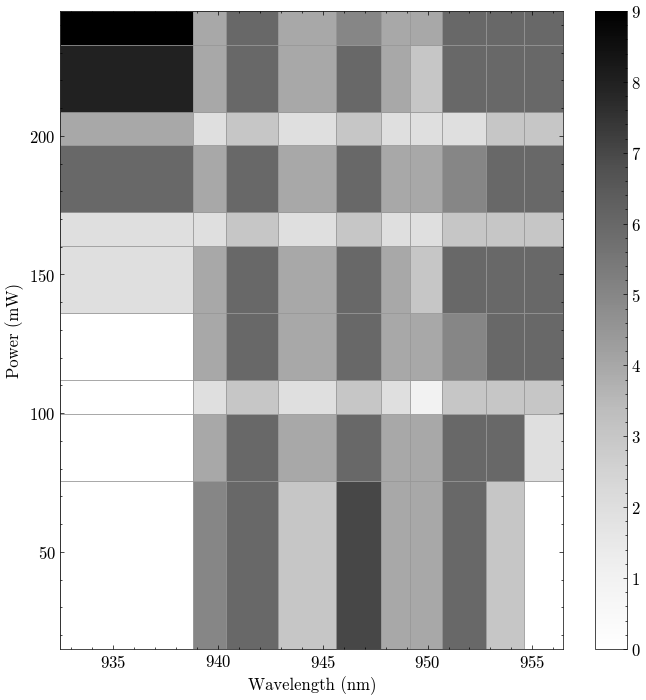

In [9]:
from physt import h2
bin_count = [10, 10]

histogram = h2(data['pca_length'][stim_pos_mask], data['power'][stim_pos_mask], 'quantile', bin_count = bin_count, name = 'Bins', axis_names=['Wavelength (nm)', 'Power (mW)'])
histogram.plot()
bins = histogram.numpy_bins #Get bins to use in numpy - Use later!


#More accurate binning when including data under threshold - may break if pca length isn't very good though
# histogram = h2(data['cavity_length'], data['power'], 'quantile', bin_count = bin_count, name = 'Bins', axis_names=['Wavelength (nm)', 'Power (mW)'])
# histogram.plot()
# bins = histogram.numpy_bins #Get bins to use in numpy - Use later!

# Basic Clustering

Kmeans

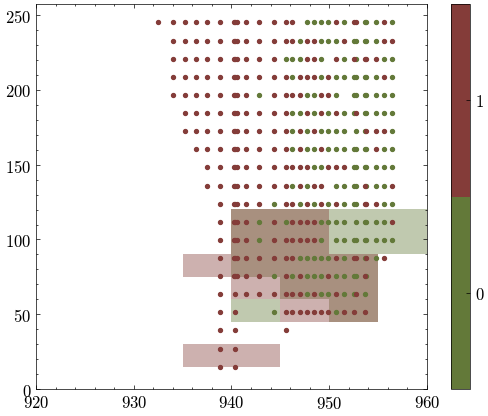

In [10]:
# Kmeans clustering on images
cluster_labels, _ = Meta_classifier.Kmeans_no_CNN(data['file'][stim_pos_mask], 2)

# Plots each cluster
fig, ax, _, _ = power_length_analysis.all_cluster_plot(
    np.amax(cluster_labels), cluster_labels,
    data['pca_length'][stim_pos_mask], data['power'][stim_pos_mask],
    'tab20b', 8, [920, 960], [0, 120], 8
)



Fuzzy CMeans

In [14]:
fuzzy_label, alpha, mem_mat = Meta_classifier.quick_fcmeans(data['flat_image'][stim_pos_mask], 3, 1.5, return_matrix=True)

C:\Users\Pouis\AppData\Local\Temp\ipykernel_15452\206121886.py:22: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


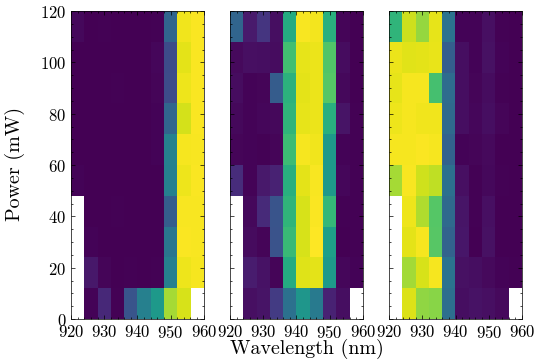

In [16]:
#num plots, num columns, num rows
fig, axes, gs = power_length_analysis.grid_plot(3, 3, 1, 0.5, 0.5)

for i, col in enumerate(mem_mat):
    # power_length_analysis.plot_2dhist(
    #     data['pca_length'][~stim_mask],
    #     data['power'][~stim_mask],
    #     [920, 960], [0, 240],
    #     'grey', 15, fig=fig, ax=axes[i], alpha=1
    # )

    power_length_analysis.plot_2d_stat_hist(
        data['pca_length'][stim_pos_mask],
        data['power'][stim_pos_mask],
        col,
        [920, 960], [0, 120], bins=bins,
        cmap='viridis', fig=fig, ax=axes[i], facecolor='darkgrey'
    )

fig.supxlabel('Wavelength (nm)')
fig.supylabel('Power (mW)')
plt.tight_layout()
plt.show()

In [41]:
fuzzy_label[-1] = -1
power_length_analysis.interactive_scatter(data['pca_length'][stim_pos_mask], data['power'][stim_pos_mask],
                                          data['file'][stim_pos_mask], labels_data=fuzzy_label)

# CNN

Make Predictions

In [17]:
if socket.gethostname() == 'Louis_PC':
    model_root = r'C:\Users\Pouis\Documents\Uni Shit\Masters\PhaseGit\Supervised-clustering-phase-pBEC\MultiMode Analysis\Models\220824_conf_'
    save_path = model_root + f'{t_chunks[0][0]}_{t_chunks[-1][-1]}_predictions'
# %matplotlib qt
with open(model_root + 'model_parameters.json', 'r') as f:
    model_params = json.load(f)

phases = len(model_params['training args']['modes'])

In [18]:
try: 
    with open(save_path + f'_{displacements[dataset]:.2f}.json', 'r') as f:
        conf_outs = json.load(f)


except:
    feat_vectors = Meta_classifier.predeict_images_CNN(data['file'][stim_pos_mask], root = model_root, phases = 4, sigm=[0.1,0.1])
    outputs, preds = Meta_classifier.predict_full_output(data['file'][stim_pos_mask], root = model_root, phases = 4, sigm= [0.1,0.1])

    conf_outs = {
        'feature_vectors': feat_vectors.tolist(),
        'outputs': outputs.tolist(),
        'predictions': preds.tolist()
    }

    with open(save_path + f'_{displacements[dataset]:.2f}.json', 'w') as f:
        json.dump(conf_outs,f)

finally:
    # Numpy arrays arent json serialisable so lists used instead, converting back to numpy arrays
    for i, (key, val) in enumerate(zip(conf_outs.keys(), conf_outs.values())):
        conf_outs.update({key: np.array(val)})

Confidence plot

Text(0.02, 0.5, 'Pump Power $mW$')

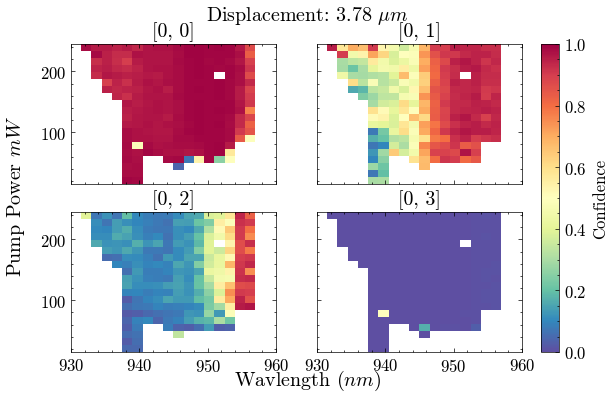

In [19]:
#Scale for all colorbars
vs = [np.min(conf_outs['outputs']), np.max(conf_outs['outputs'])]

# Creates grid of axis objects
fig, axes, gs = power_length_analysis.grid_plot(
    nplots=phases, ncols=2, nrows=2,
    wspace=0.2, hspace=0.2)

for i in range(conf_outs['outputs'].shape[1]):
    # Selects output of particular model
    mode_conf = conf_outs['outputs'][:, i, 0]

    # plots histogram, returns plot object and the histogram
    # replace bins with the physt 'bins' variable to use quantile non-uniform binning (bins = bins)
    _, _, plot, stat = power_length_analysis.plot_2d_stat_hist(data['pca_length'][stim_pos_mask],
                                                               data['power'][stim_pos_mask],
                                                               mode_conf, [930, 960],
                                                               [min(data['power']), max(data['power'])], bins=20,
                                                               cmap='Spectral_r',
                                                               fig=fig, ax=axes[i], vs=vs, ret_stat=True)
    
    axes[i].set_title(model_params['training args']['modes'][i]['mode'])

# print(np.min(preds))

# Adds colorbar to colorbar axis
cbax = plt.subplot(gs[1])
plt.colorbar(plot, cbax, cmap='Spectral_r', label='Confidence', )

fig.suptitle(f'Displacement: {displacements[dataset]:.2f} $\mu m$')
fig.supxlabel('Wavlength $(nm)$')
fig.supylabel('Pump Power $mW$')



# MULTIRUN!

Grid plot - threshold not threshold

In [20]:
# Calculates params for grid plots
from math import ceil
nplots = len(positions)
nrows = 2
ncols = ceil(nplots / nrows)

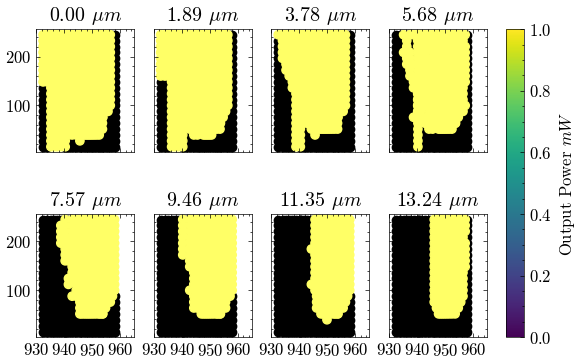

In [21]:
fig, axes, gs = power_length_analysis.grid_plot(nplots, ncols, nrows, wspace=0.5, hspace=0.5)

vs = [np.amin(data['meter_reading'][stim_mask]), np.amax(data['meter_reading'][stim_mask])]

cmap = 'summer'

for i, (disp, pos) in enumerate(zip(displacements, positions)):
    # create mask for dataset
    pos_mask = select_files.select_position(data, pos)
    thermal_mask = pos_mask & (~stim_mask)
    sp_mask = pos_mask & stim_mask

    scat = axes[i].scatter(data['pca_length'][thermal_mask], data['power'][thermal_mask], color='black', label='Below Threshold')

    axes[i].scatter(data['pca_length'][sp_mask], data['power'][sp_mask], c=data['meter_reading'][sp_mask]*1e3,
                  cmap=cmap, label='Above Threshold', vmin = vs[0], vmax = vs[1])
    
    axes[i].set_xlim([930,965])

    axes[i].set_title(f'{disp:.2f} $\mu m$')

cbax = plt.subplot(gs[1])
plt.colorbar(scat, cbax, cmap = cmap, label = "Output Power $mW$")

plt.show()
    



Predict entire dataset with BEC not BEC model (will take a while)

In [22]:
if socket.gethostname() == 'Louis_PC':
    model_root = r'C:\Users\Pouis\Documents\Uni Shit\Masters\PhaseGit\Supervised-clustering-phase-pBEC\MultiMode Analysis\Models\220824_multi_'
    save_path = model_root + f'{t_chunks[0][0]}_{t_chunks[-1][-1]}_predictions'

In [23]:
# Tries to load any previous predictions made
try:
    with open(save_path + '.json', 'r') as f:
        cnn_outs = json.load(f)

except:
    # If no predictions exist, runs cnn
    feat_vectors = Meta_classifier.predeict_images_CNN(data['file'][stim_mask], root = model_root, phases = 1, sigm=[0.1,0.1])
    outputs, preds = Meta_classifier.predict_full_output(data['file'][stim_mask], root = model_root, phases = 1, sigm= [0.1,0.1])

    cnn_outs = {
        'feature_vectors': feat_vectors.tolist(),
        'outputs': outputs.tolist(),
        'predictions': preds.tolist()
    }

    # to be loaded later 
    with open(save_path + '.json', 'w') as f:
        json.dump(cnn_outs,f)

finally:
    # converts back to numpy arrays
    for i, (key, val) in enumerate(zip(cnn_outs.keys(), cnn_outs.values())):
        cnn_outs.update({key: np.array(val)})

0it [00:00, ?it/s]C:\Users\Pouis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\transforms\v2\_deprecated.py:41: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.
  warnings.warn(
2888it [03:55, 12.25it/s]
0it [00:00, ?it/s]C:\Users\Pouis\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torchvision\transforms\v2\_deprecated.py:41: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.
  warnings.warn(
2888it [03:44, 12.88it/s]


BEC not BEC plot

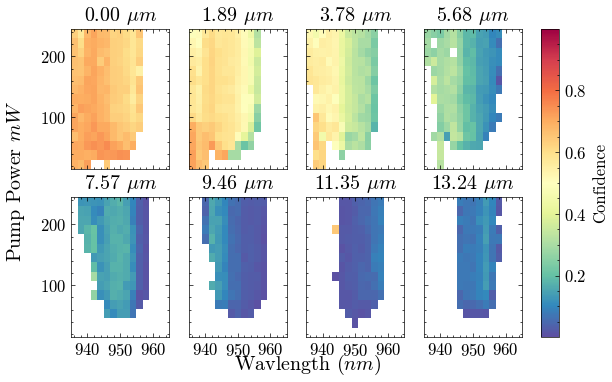

In [24]:
from physt import h2
# similar to mode confidence plot

bin_count = [10, 10]
cmap = 'Spectral_r'
vs = [np.min(cnn_outs['outputs']), np.max(cnn_outs['outputs'])]

fig, axes, gs = power_length_analysis.grid_plot(
    nplots=nplots, ncols=ncols, nrows=nrows,
    wspace=0.2, hspace=0.2)

stim_data = {}

for k,v in zip(data.keys(), data.values()):
    stim_data.update({k: v[stim_mask]})


for i, (disp, pos) in enumerate(zip(displacements, positions)):
    pos_mask = select_files.select_position(stim_data, pos)

    histogram = h2(stim_data['cavity_length'][pos_mask], stim_data['power'][pos_mask], 'quantile', bin_count = bin_count, name = 'Bins', axis_names=['Wavelength (nm)', 'Power (mW)'])
    bins = histogram.numpy_bins

    conf = cnn_outs['outputs'][:, 0, 0][pos_mask]
    _, _, plot, stat = power_length_analysis.plot_2d_stat_hist(stim_data['pca_length'][pos_mask],
                                                               stim_data['power'][pos_mask],
                                                               conf, [935, 965],
                                                               [min(data['power']), max(data['power'])], bins=15,
                                                               cmap=cmap,
                                                               fig=fig, ax=axes[i], vs=vs, ret_stat=True)
    
    axes[i].set_title(f'{disp:.2f} $\mu m$')


cbax = plt.subplot(gs[1])
plt.colorbar(plot, cbax, cmap=cmap, label='Confidence', )

fig.supxlabel('Wavlength $(nm)$')
fig.supylabel('Pump Power $mW$')

plt.show()
